In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from typing import Tuple, List, Dict, Optional

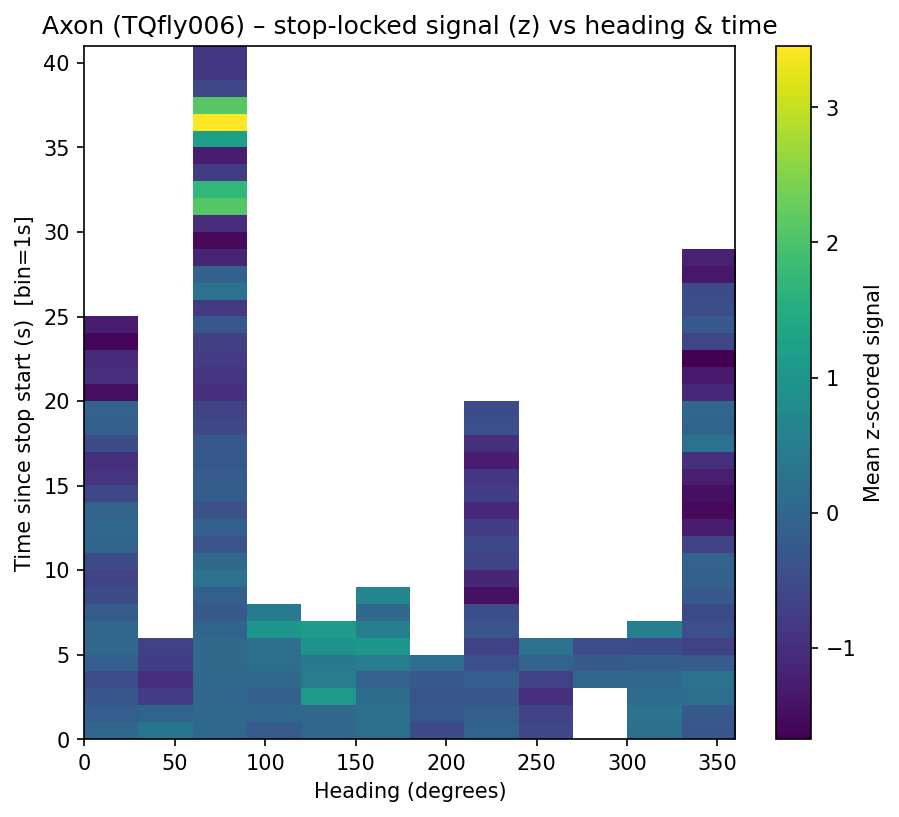

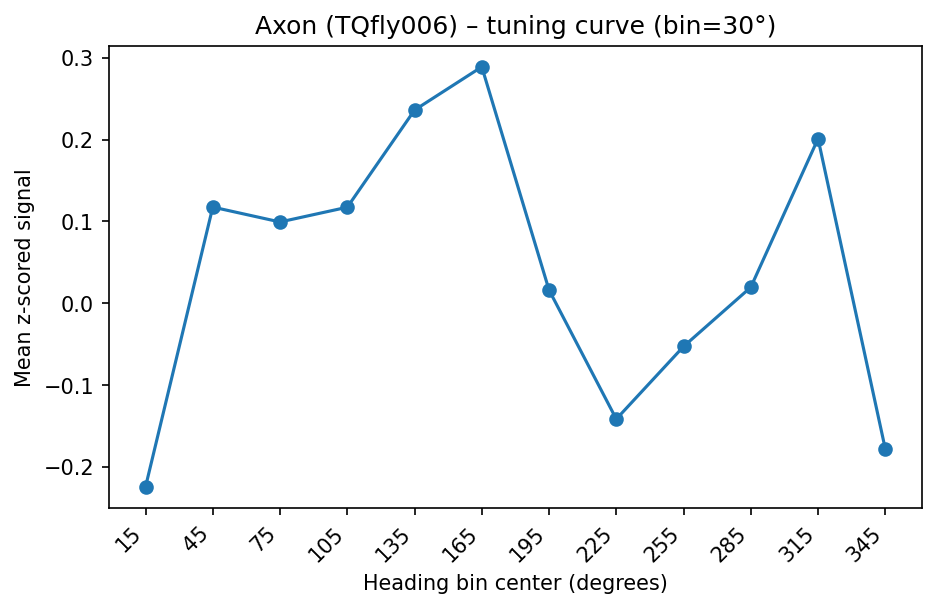

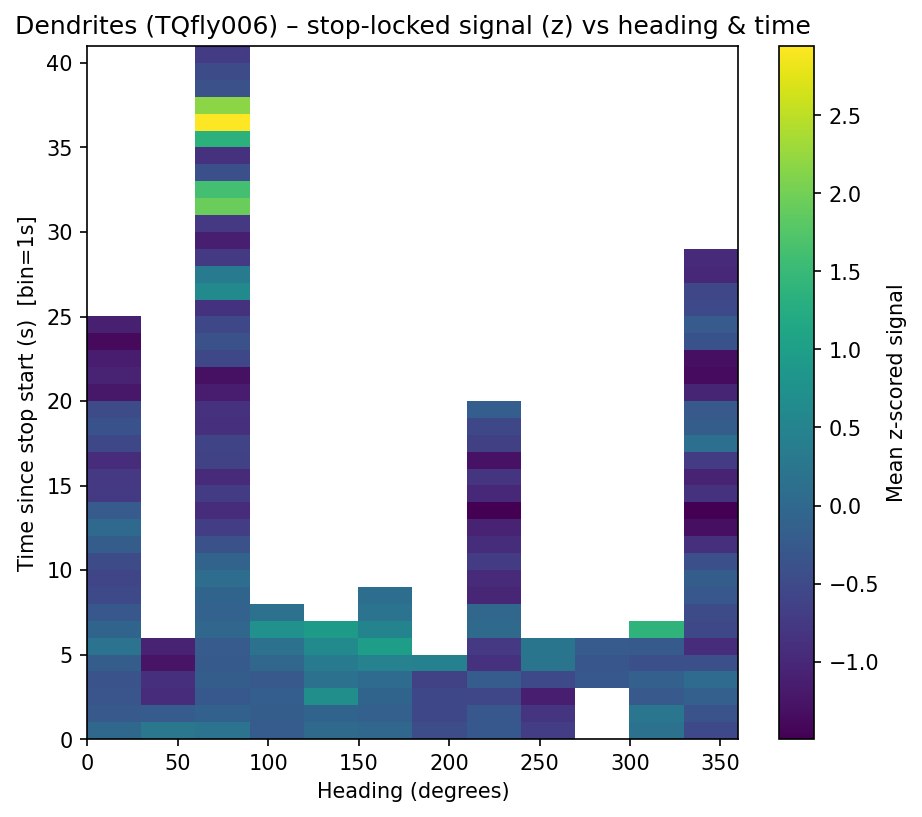

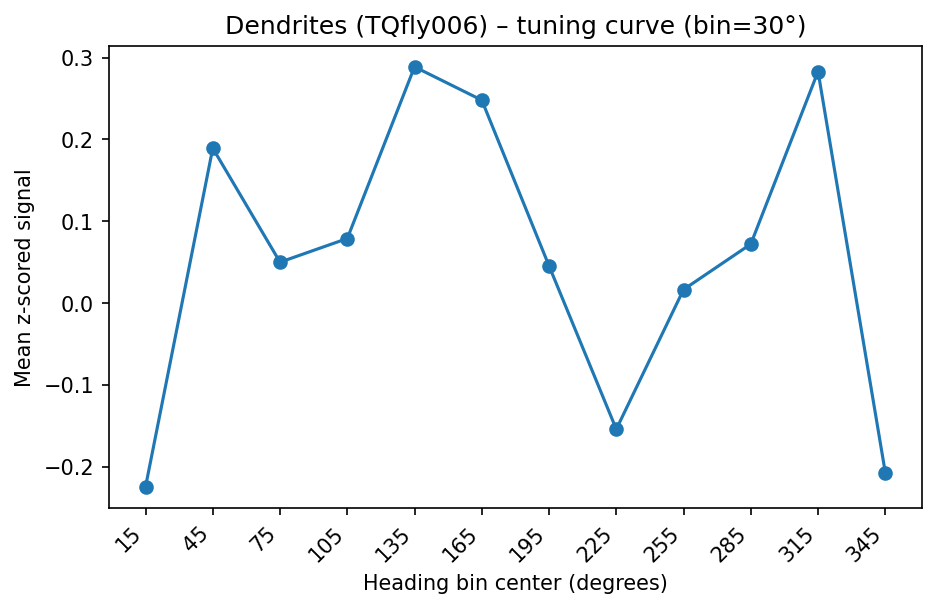

In [17]:
# =========================
# Config (editable)
# =========================
SAVE_FIGS = False
BIN_DEG = 30
TIME_BIN_S = 1.0
STOP_SPEED_THRESH_DEG_S = 15
MIN_STOP_S = 1.0
MAX_HEATMAP_TIME_S = None  # e.g., 20.0

# NEW: polarity option — set per trace:
# 'positive'  -> larger signal = more activity (no change)
# 'negative'  -> smaller signal = more activity (flip sign after z-score)
POLARITY = {
    "axon": "negative",
    "dendrites": "negative",
}

# Default inputs (you can call analyze() with your own)
DEFAULT_INPUT = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/R55G08_SPARC_S_ASAP7y/dark"  # file or a directory
DEFAULT_FLY_PREFIX = "TQfly006"  # e.g., "TQfly001" when DEFAULT_INPUT is a directory


# =========================
# Helpers
# =========================
def wrap_to_360(deg):
    return np.mod(deg, 360.0)

def heading_bins_edges(bin_deg: int) -> np.ndarray:
    return np.arange(0, 360 + 1e-9, bin_deg)

def zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    m, s = np.nanmean(x), np.nanstd(x)
    if not np.isfinite(s) or s == 0:
        return np.zeros_like(x, dtype=float)
    return (x - m) / s

def apply_polarity(z: np.ndarray, mode: str) -> np.ndarray:
    """
    mode: 'positive' (no change) or 'negative' (flip sign so that higher = more activity)
    """
    mode = (mode or "positive").lower()
    if mode == "negative":
        return -z
    return z

def contiguous_true_runs(mask: np.ndarray) -> List[tuple]:
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]
    return list(zip(starts, ends))


# =========================
# Core computation
# =========================
def build_stop_heatmap_sums(time_s: np.ndarray,
                            heading_deg_0_360: np.ndarray,
                            signal_z: np.ndarray,
                            ang_speed_deg_s: np.ndarray,
                            bin_deg: int = 30,
                            time_bin_s: float = 1.0,
                            stop_thresh_deg_s: float = 15.0,
                            min_stop_s: float = 1.0,
                            max_time_s: Optional[float] = None):
    """
    Accumulate SUM and COUNT of z-scored signal per (time-bin, heading-bin) during stop epochs.
    Returns (sums 2D, counts 2D, x_edges, y_edges)
    """
    stopped = np.abs(ang_speed_deg_s) <= stop_thresh_deg_s
    runs = contiguous_true_runs(stopped)
    if not runs:
        return None, None, None, None

    x_edges = heading_bins_edges(bin_deg)
    n_x = len(x_edges) - 1

    durations = []
    for s, e in runs:
        dur = time_s[e - 1] - time_s[s]
        if dur >= min_stop_s:
            durations.append(dur)
    if not durations:
        return None, None, x_edges, None

    max_dur = max(durations)
    if max_time_s is not None:
        max_dur = min(max_dur, max_time_s)
    n_y = int(np.floor(max_dur / time_bin_s)) + 1

    sums = np.zeros((n_y, n_x), float)
    counts = np.zeros((n_y, n_x), int)

    for s, e in runs:
        dur = time_s[e - 1] - time_s[s]
        if dur < min_stop_s:
            continue
        t0 = time_s[s]
        for i in range(s, e):
            t_rel = time_s[i] - t0
            if t_rel < 0:
                continue
            y_idx = int(np.floor(t_rel / time_bin_s))
            if y_idx < 0 or y_idx >= n_y:
                continue
            x_idx = int(np.floor(heading_deg_0_360[i] / bin_deg)) % n_x
            val = signal_z[i]
            if np.isfinite(val):
                sums[y_idx, x_idx] += val
                counts[y_idx, x_idx] += 1

    y_edges = np.arange(0, n_y + 1, 1.0) * time_bin_s
    return sums, counts, x_edges, y_edges

def tuning_curve(signal_z: np.ndarray,
                 heading_deg_0_360: np.ndarray,
                 bin_deg: int = 30):
    x_edges = heading_bins_edges(bin_deg)
    n_x = len(x_edges) - 1
    sums = np.zeros(n_x, float)
    counts = np.zeros(n_x, int)
    idx = np.floor(heading_deg_0_360 / bin_deg).astype(int) % n_x
    for b in range(n_x):
        sel = idx == b
        c = int(np.sum(sel))
        if c > 0:
            sums[b] = float(np.nansum(signal_z[sel]))
            counts[b] = c
    x_centers = x_edges[:-1] + bin_deg / 2.0
    means = np.divide(sums, counts, out=np.full_like(sums, np.nan), where=counts>0)
    return x_centers, means, counts, sums


def load_trial_csv(csv_path: str, polarity: Dict[str, str]) -> Dict[str, np.ndarray]:
    df = pd.read_csv(csv_path)

    # sort by time just in case
    time_s = df['Time_Stamp'].to_numpy(float)
    order = np.argsort(time_s)
    if not np.all(order == np.arange(len(time_s))):
        df = df.iloc[order].reset_index(drop=True)
        time_s = df['Time_Stamp'].to_numpy(float)

    heading_wrapped_rad = df['Bar_Position/Heading'].to_numpy(float)
    heading_deg = np.degrees(heading_wrapped_rad)
    heading_deg_0_360 = wrap_to_360(heading_deg)
    ang_speed_deg_s = np.degrees(df['Angular_Velocity'].to_numpy(float))

    # z-score per TRIAL per TRACE, then apply polarity
    axon_z = apply_polarity(zscore(df['F_background_subtracted_axon'].to_numpy(float)), polarity.get("axon", "positive"))
    dend_z = apply_polarity(zscore(df['F_background_subtracted_dendrites'].to_numpy(float)), polarity.get("dendrites", "positive"))

    return {
        "time_s": time_s,
        "heading_deg_0_360": heading_deg_0_360,
        "ang_speed_deg_s": ang_speed_deg_s,
        "axon_z": axon_z,
        "dend_z": dend_z
    }


def aggregate_heatmaps(acc_sums: Optional[np.ndarray],
                       acc_counts: Optional[np.ndarray],
                       sums: np.ndarray, counts: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    if acc_sums is None:
        return sums.copy(), counts.copy()
    max_y = max(acc_sums.shape[0], sums.shape[0])
    max_x = max(acc_sums.shape[1], sums.shape[1])
    def pad(a, shape):
        out = np.zeros(shape, dtype=a.dtype)
        out[:a.shape[0], :a.shape[1]] = a
        return out
    acc_sums = pad(acc_sums, (max_y, max_x))
    acc_counts = pad(acc_counts, (max_y, max_x))
    sums = pad(sums, (max_y, max_x))
    counts = pad(counts, (max_y, max_x))
    acc_sums += sums
    acc_counts += counts
    return acc_sums, acc_counts


# =========================
# Plotters
# =========================
def plot_heatmap_from_sums_counts(label: str,
                                  sums: np.ndarray,
                                  counts: np.ndarray,
                                  x_edges: np.ndarray,
                                  y_edges: np.ndarray):
    means = np.divide(sums, counts, out=np.full_like(sums, np.nan, dtype=float), where=counts>0)
    fig, ax = plt.subplots(figsize=(7,6), dpi=150)
    im = ax.imshow(
        means, origin='lower', aspect='auto',
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[0] + means.shape[0]*(y_edges[1]-y_edges[0])]
    )
    ax.set_xlabel("Heading (degrees)")
    ax.set_ylabel(f"Time since stop start (s)  [bin={TIME_BIN_S:.0f}s]")
    ax.set_title(f"{label} – stop-locked signal (z) vs heading & time")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Mean z-scored signal")
    plt.show()

    if SAVE_FIGS:
        fname = f"/mnt/data/{label.replace(' ', '_')}_stop_heatmap_{BIN_DEG}deg_{TIME_BIN_S:.0f}s.png"
        fig.tight_layout()
        fig.savefig(fname, bbox_inches='tight')
        plt.close(fig)
        return fname
    plt.close(fig)
    return None

def plot_tuning_curve(label: str, x_centers: np.ndarray, sums: np.ndarray, counts: np.ndarray):
    means = np.divide(sums, counts, out=np.full_like(sums, np.nan, dtype=float), where=counts>0)
    fig, ax = plt.subplots(figsize=(7,4), dpi=150)
    ax.plot(x_centers, means, marker='o')
    ax.set_xlabel("Heading bin center (degrees)")
    ax.set_ylabel("Mean z-scored signal")
    ax.set_title(f"{label} – tuning curve (bin={BIN_DEG}°)")
    ax.set_xticks(x_centers)
    ax.set_xticklabels([f"{int(x)}" for x in x_centers], rotation=45, ha='right')
    plt.show()

    if SAVE_FIGS:
        fname = f"/mnt/data/{label.replace(' ', '_')}_tuning_{BIN_DEG}deg.png"
        fig.tight_layout()
        fig.savefig(fname, bbox_inches='tight')
        plt.close(fig)
        return fname
    plt.close(fig)
    return None


# =========================
# High-level API
# =========================
def analyze(input_path: str,
            fly_prefix: Optional[str] = None,
            polarity: Optional[Dict[str, str]] = None):
    """
    polarity: dict like {"axon": "positive"|"negative", "dendrites": "positive"|"negative"}
    """
    saved = []
    polarity = polarity or POLARITY

    if os.path.isfile(input_path):
        # single-trial
        trial = load_trial_csv(input_path, polarity)
        for label, sig in {"Axon": trial["axon_z"], "Dendrites": trial["dend_z"]}.items():
            # heatmap
            sums, counts, x_edges, y_edges = build_stop_heatmap_sums(
                time_s=trial["time_s"],
                heading_deg_0_360=trial["heading_deg_0_360"],
                signal_z=sig,
                ang_speed_deg_s=trial["ang_speed_deg_s"],
                bin_deg=BIN_DEG,
                time_bin_s=TIME_BIN_S,
                stop_thresh_deg_s=STOP_SPEED_THRESH_DEG_S,
                min_stop_s=MIN_STOP_S,
                max_time_s=MAX_HEATMAP_TIME_S
            )
            if sums is not None:
                fname = plot_heatmap_from_sums_counts(label, sums, counts, heading_bins_edges(BIN_DEG), np.arange(0, sums.shape[0]+1)*TIME_BIN_S)
                if fname: saved.append(fname)

            # tuning
            x_centers, means_tc, counts_tc, sums_tc = tuning_curve(sig, trial["heading_deg_0_360"], BIN_DEG)
            fname = plot_tuning_curve(label, x_centers, sums_tc, counts_tc)
            if fname: saved.append(fname)

        return saved

    # directory mode
    if not os.path.isdir(input_path):
        raise ValueError("input_path must be an existing file or directory")

    if not fly_prefix:
        raise ValueError("When analyzing a directory, please provide fly_prefix like 'TQfly001'")

    csvs = [os.path.join(input_path, f) for f in os.listdir(input_path)
            if f.startswith(fly_prefix + "-") and f.endswith(".csv")]
    if len(csvs) == 0:
        raise ValueError(f"No CSVs found for fly prefix '{fly_prefix}' in {input_path}")

    acc = {
        "Axon": {"sums": None, "counts": None},
        "Dendrites": {"sums": None, "counts": None},
    }
    x_centers = heading_bins_edges(BIN_DEG)[:-1] + BIN_DEG/2.0
    tc = {
        "Axon": {"sums": np.zeros_like(x_centers), "counts": np.zeros_like(x_centers, dtype=int)},
        "Dendrites": {"sums": np.zeros_like(x_centers), "counts": np.zeros_like(x_centers, dtype=int)},
    }

    for p in sorted(csvs):
        trial = load_trial_csv(p, polarity)
        for label, sig_key in [("Axon", "axon_z"), ("Dendrites", "dend_z")]:
            sums, counts, x_edges, y_edges = build_stop_heatmap_sums(
                time_s=trial["time_s"],
                heading_deg_0_360=trial["heading_deg_0_360"],
                signal_z=trial[sig_key],
                ang_speed_deg_s=trial["ang_speed_deg_s"],
                bin_deg=BIN_DEG,
                time_bin_s=TIME_BIN_S,
                stop_thresh_deg_s=STOP_SPEED_THRESH_DEG_S,
                min_stop_s=MIN_STOP_S,
                max_time_s=MAX_HEATMAP_TIME_S
            )
            if sums is not None:
                acc[label]["sums"], acc[label]["counts"] = aggregate_heatmaps(
                    acc[label]["sums"], acc[label]["counts"], sums, counts
                )
            x_c, means_tc, counts_tc, sums_tc = tuning_curve(trial[sig_key], trial["heading_deg_0_360"], BIN_DEG)
            tc[label]["sums"] += sums_tc
            tc[label]["counts"] += counts_tc

    for label in ["Axon", "Dendrites"]:
        sums = acc[label]["sums"]
        counts = acc[label]["counts"]
        if sums is not None:
            fname = plot_heatmap_from_sums_counts(
                f"{label} ({fly_prefix})",
                sums, counts,
                heading_bins_edges(BIN_DEG),
                np.arange(0, sums.shape[0]+1)*TIME_BIN_S
            )
            if fname: saved.append(fname)
        fname = plot_tuning_curve(
            f"{label} ({fly_prefix})",
            x_centers, tc[label]["sums"], tc[label]["counts"]
        )
        if fname: saved.append(fname)

    return saved


# =========================
# Demo run (single-trial using default)
# =========================
_ = analyze(DEFAULT_INPUT, DEFAULT_FLY_PREFIX, polarity=POLARITY)